# Classification Machine Learning Assignment

## Framingham Heart Disease Prediction

This project performs complete preprocessing, missing value handling, feature scaling, class balancing, classification model implementation, model comparison, hyperparameter tuning, and final evaluation using the Framingham Heart Disease dataset.

### Target Variable
`TenYearCHD`

The target variable indicates whether a patient is at risk of developing coronary heart disease within ten years.

In [28]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Dataset

The Framingham dataset is loaded from the CSV file.

In [29]:
# Load dataset

df = pd.read_csv("framingham.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (4238, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## 2. Dataset Overview

We inspect the structure, data types, missing values, duplicate records, and statistical summary of the dataset.

In [30]:
# Dataset information

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (4238, 16)

Column Names:
['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']

Data Types:
male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

Missing Values:
male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI             

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


## 3. Target Variable Distribution

The target variable `TenYearCHD` is checked to identify whether the dataset is balanced or imbalanced.

TenYearCHD
0    3594
1     644
Name: count, dtype: int64

Target Percentage:
TenYearCHD
0    84.8
1    15.2
Name: proportion, dtype: float64


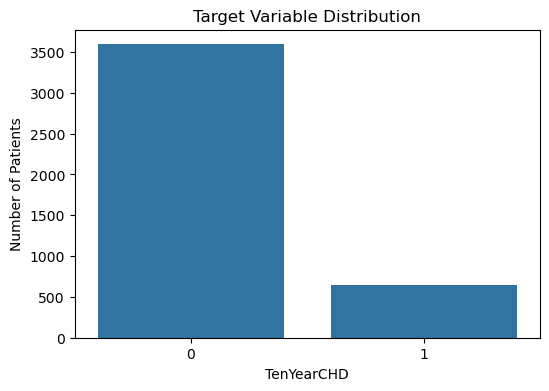

In [31]:
# Target distribution

print(df["TenYearCHD"].value_counts())

print("\nTarget Percentage:")
print((df["TenYearCHD"].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(6,4))
sns.countplot(x="TenYearCHD", data=df)
plt.title("Target Variable Distribution")
plt.xlabel("TenYearCHD")
plt.ylabel("Number of Patients")
plt.show()

## 4. Data Preprocessing

The dataset contains missing values in several columns. Missing numerical values will be replaced using the median because median imputation is less affected by extreme values.

Duplicate records are also checked and removed if present.

In [32]:
# Remove duplicate rows

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

# Separate features and target

X = df.drop("TenYearCHD", axis=1)
y = df["TenYearCHD"]

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

Shape after removing duplicates: (4238, 16)

Features shape: (4238, 15)
Target shape: (4238,)


## 5. Train-Test Split

The dataset is divided into training and testing sets.

Stratified splitting is used so that the proportion of both target classes remains similar in training and testing data.

In [33]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

Training data: (3390, 15)
Testing data: (848, 15)

Training target distribution:
TenYearCHD
0    2875
1     515
Name: count, dtype: int64


## 6. Preprocessing, Scaling and Class Balancing

A machine learning pipeline is used to avoid data leakage.

Steps:

1. Missing values are filled using median imputation.
2. Features are standardized using StandardScaler.
3. SMOTE is applied only to the training data to handle class imbalance.

In [34]:
# Preprocessing pipeline

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Transform training data

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Apply SMOTE only on training data

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

Before SMOTE:
TenYearCHD
0    2875
1     515
Name: count, dtype: int64

After SMOTE:
TenYearCHD
0    2875
1    2875
Name: count, dtype: int64


## 7. Classification Models

The following classification algorithms will be implemented and compared:

- Logistic Regression
- K-Nearest Neighbors
- Decision Tree
- Random Forest
- Support Vector Machine

In [35]:
# Define classification models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42)
}

results = []

for name, model in models.items():
    
    model.fit(X_train_balanced, y_train_balanced)
    
    y_pred = model.predict(X_test_processed)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.792453,0.229885,0.155039,0.185185
1,Decision Tree,0.724057,0.213115,0.302326,0.250000
2,SVM,0.696934,0.239837,0.457364,0.314667
3,Logistic Regression,0.665094,0.249191,0.596899,0.351598
4,KNN,0.642689,0.211921,0.496124,0.296984


## 8. Model Performance Comparison

The models are compared using Accuracy, Precision, Recall and F1-Score.

A higher value indicates better classification performance.### 

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.792453,0.229885,0.155039,0.185185
1,Decision Tree,0.724057,0.213115,0.302326,0.250000
2,SVM,0.696934,0.239837,0.457364,0.314667
3,Logistic Regression,0.665094,0.249191,0.596899,0.351598
4,KNN,0.642689,0.211921,0.496124,0.296984


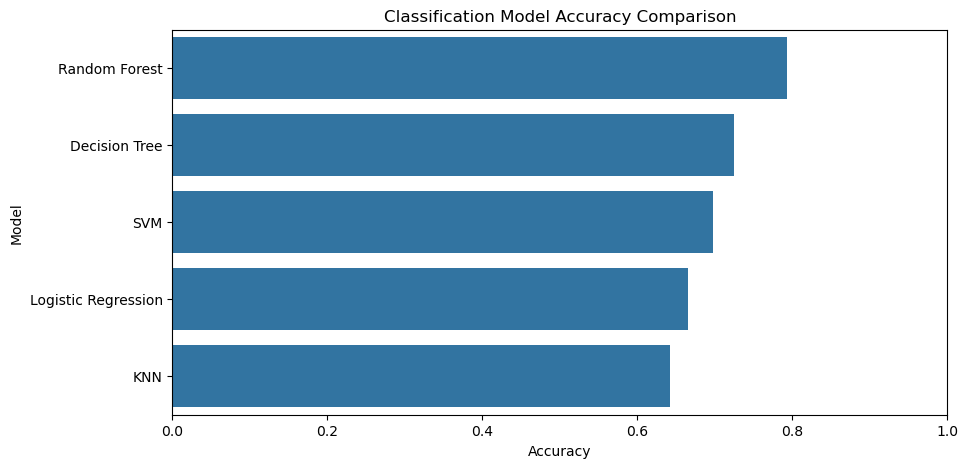

In [36]:
# Display model comparison

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(results_df)

# Plot accuracy comparison

plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model"
)

plt.title("Classification Model Accuracy Comparison")
plt.xlim(0, 1)
plt.show()

## 9. Hyperparameter Tuning

The best-performing model is further optimized using GridSearchCV.

Hyperparameter tuning searches for the best combination of parameters to improve model performance.

In [37]:
# Hyperparameter tuning for Random Forest

rf_pipeline = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best Cross-Validation Accuracy:
0.8144542772861356


## 10. Final Model Evaluation

The optimized Random Forest model is evaluated on the unseen test dataset using:

- Accuracy
- Precision
- Recall
- F1-Score
- Classification Report
- Confusion Matrix

In [38]:
# Final optimized model

best_model = grid_search.best_estimator_

y_pred_final = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_final)
precision = precision_score(y_test, y_pred_final)
recall = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)

print("Final Model Performance")
print("=" * 40)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

Final Model Performance
Accuracy : 0.796
Precision: 0.2442
Recall   : 0.1628
F1-Score : 0.1953


## 11. Classification Report

In [39]:
# Classification report

print("Classification Report")
print("=" * 50)

print(classification_report(
    y_test,
    y_pred_final
))

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       719
           1       0.24      0.16      0.20       129

    accuracy                           0.80       848
   macro avg       0.55      0.54      0.54       848
weighted avg       0.76      0.80      0.78       848



## 12. Confusion Matrix

The confusion matrix shows the number of correctly and incorrectly classified observations for each class.

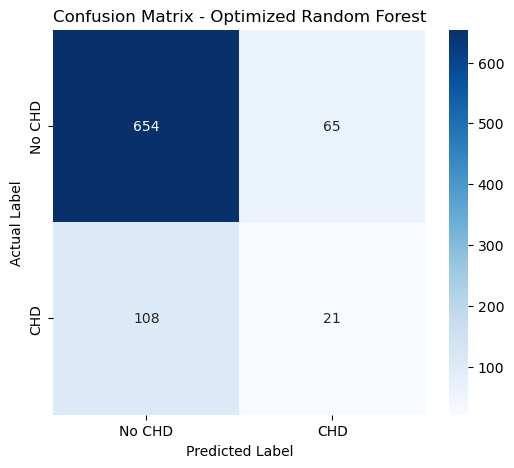

In [40]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No CHD", "CHD"],
    yticklabels=["No CHD", "CHD"]
)

plt.title("Confusion Matrix - Optimized Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## 13. Final Conclusion

The Framingham dataset was successfully preprocessed by handling missing values and removing duplicate records. Feature scaling was applied using StandardScaler and class imbalance was addressed using SMOTE.

Multiple classification algorithms were implemented and compared using Accuracy, Precision, Recall and F1-Score.

The Random Forest model was further optimized using GridSearchCV. The optimized model was evaluated using the classification report and confusion matrix.

The final model provides the best optimized classification performance among the evaluated models.

## 14. Final Model Performance Summary

The following table presents the performance of the final optimized model using Accuracy, Precision, Recall, and F1-Score.

In [41]:
# Final Model Performance Summary

final_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [accuracy, precision, recall, f1]
})

display(final_summary)

,Metric,Score
0,Accuracy,0.795991
1,Precision,0.244186
2,Recall,0.162791
3,F1-Score,0.195349


## 15. Final Performance Visualization

The performance metrics of the final optimized model are visualized below.

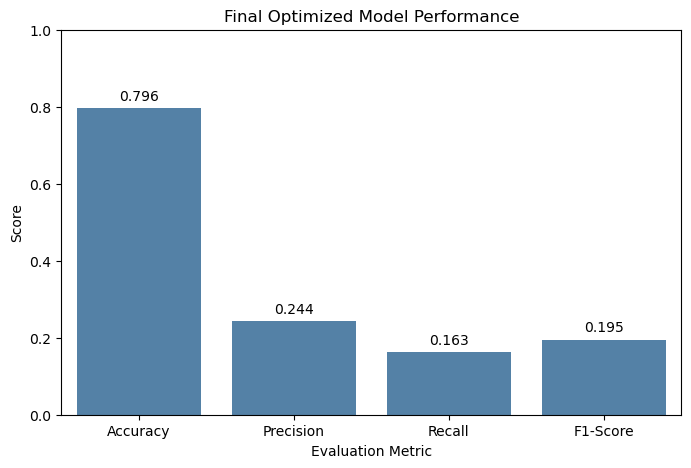

In [42]:
# Visualize final model performance

plt.figure(figsize=(8, 5))

sns.barplot(
    x="Metric",
    y="Score",
    data=final_summary,
    color="steelblue"
)

plt.ylim(0, 1)
plt.title("Final Optimized Model Performance")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

for i, score in en# Visualize final model performance

plt.figure(figsize=(8, 5))

sns.barplot(
    x="Metric",
    y="Score",
    data=final_summary,
    color="steelblue"
)

plt.ylim(0, 1)
plt.title("Final Optimized Model Performance")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

for i, score in enumerate(final_summary["Score"]):
    plt.text(i, score + 0.02, f"{score:.3f}", ha="center")

plt.show()

plt.show()